# Week 4 Task: Supervised Learning Model Implementation
## Medical Classification – Breast Cancer Diagnosis

**Objective**  
Build a supervised learning classification model that predicts whether a breast tumor is **malignant** or **benign** using the Wisconsin Breast Cancer dataset.

**What this notebook covers**
1. Loading and exploring the data
2. Data preprocessing and feature engineering
3. Training multiple classification models
4. Cross-validation and hyperparameter tuning
5. Evaluation with medical-relevant metrics
6. Feature importance and interpretation
7. Discussion of strengths, limitations and improvements

**Dataset:** Wisconsin Breast Cancer (Diagnostic) – available in scikit-learn  
**Problem Type:** Binary Classification

## 1. Import Libraries

We import the libraries needed for data handling, visualization, preprocessing, modeling and evaluation.

In [7]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
    --------------------------------------- 0.8/48.9 MB 2.1 MB/s eta 0:00:23
   - -------------------------------------- 1.3/48.9 MB 2.5 MB/s eta 0:00:20
   - -------------------------------------- 2.1/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 2.6/48.9 MB 3.0 MB/s eta 0:00:16
   -- ------------------------------------- 3.1/48.9 MB 2.8 MB/s eta 0:00:17
   -- ------------------------------------- 3.7/48.9 MB 2.8 MB/s eta 0:00:17
   --- ------------------------------------ 4.5/48.9 MB 2.9 MB/s eta 0:00:16
   ---- ----------------------------------- 5.2/48.9 MB 3.0 MB/s eta 0:00:15
   ----- ---------------------------------- 6.3/48.9 MB 3.2 MB/s eta 0:00:14
   ------ --------------------------------- 7.6/48.9 MB 3.5 MB/s eta 0:00:12
   ------- -------------------------------- 8.9/48.9 MB 3.8 MB/s eta 0:00:11
   -------- -

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_theme(style="whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Dataset

**Why this dataset?**  
The Wisconsin Breast Cancer (Diagnostic) dataset is a standard public medical dataset.  
It contains features computed from digitized images of fine-needle aspirates of breast masses.  
The goal is to classify each sample as **malignant (0)** or **benign (1)**.

In [9]:
# Load dataset
data = load_breast_cancer()

# Create DataFrame for easier handling
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("\nTarget classes:", data.target_names)
print("\nClass distribution:")
print(y.value_counts().rename({0: 'Malignant (0)', 1: 'Benign (1)'}))
print("\nFirst 10 feature names:")
for i, col in enumerate(X.columns[:10], 1):
    print(f"  {i:2d}. {col}")
print("  ... and", len(X.columns) - 10, "more features")

Dataset shape: (569, 30)

Target classes: ['malignant' 'benign']

Class distribution:
target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64

First 10 feature names:
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  ... and 20 more features


## 3. Exploratory Data Analysis (EDA)

**Purpose of EDA**  
Before building any model we must understand the data:  
- Are there missing values or duplicates?  
- Is the class distribution balanced?  
- Which features are most related to the target?  
- Are features on similar scales?

In [10]:
# Basic statistics
print("Basic statistics of the first 8 features:")
print(X.describe().T[['mean', 'std', 'min', 'max']].round(3).head(8))

print("\nMissing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Basic statistics of the first 8 features:
                        mean      std      min       max
mean radius           14.127    3.524    6.981    28.110
mean texture          19.290    4.301    9.710    39.280
mean perimeter        91.969   24.299   43.790   188.500
mean area            654.889  351.914  143.500  2501.000
mean smoothness        0.096    0.014    0.053     0.163
mean compactness       0.104    0.053    0.019     0.345
mean concavity         0.089    0.080    0.000     0.427
mean concave points    0.049    0.039    0.000     0.201

Missing values: 0
Duplicate rows: 0


### 3.1 Class Distribution

**Why check class balance?**  
If one class is much larger, a model can get high accuracy by always predicting the majority class.  
In medical diagnosis this is dangerous because missing a malignant case (false negative) is very costly.

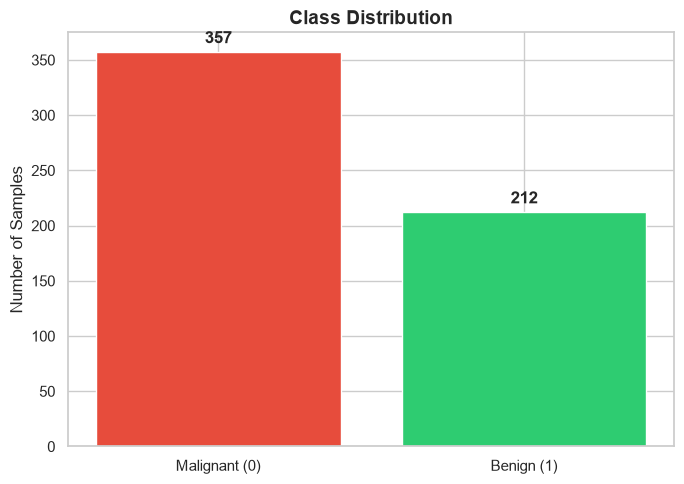

Malignant samples: 212 (37.3%)
Benign samples   : 357 (62.7%)


In [11]:
# Class distribution plot
plt.figure(figsize=(7, 5))
counts = y.value_counts()
bars = plt.bar(['Malignant (0)', 'Benign (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples')
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("Malignant samples:", counts[0], f"({counts[0]/len(y)*100:.1f}%)")
print("Benign samples   :", counts[1], f"({counts[1]/len(y)*100:.1f}%)")

### 3.2 Correlation with Target

**Why compute correlation?**  
Features that are strongly correlated with the diagnosis are more likely to be useful predictors.  
This also gives clinical insight (e.g. larger cell nuclei and more concave points indicate malignancy).

In [12]:
# Absolute correlation of each feature with the target
corr_with_target = X.apply(lambda col: col.corr(y)).abs().sort_values(ascending=False)

print("Top 10 features most correlated with target (malignancy):")
print(corr_with_target.head(10).round(3))

Top 10 features most correlated with target (malignancy):
worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
worst area              0.734
mean radius             0.730
mean area               0.709
mean concavity          0.696
worst concavity         0.660
dtype: float64


### 3.3 Correlation Heatmap

**Why a heatmap?**  
Many features measure similar things (radius, perimeter, area).  
High multicollinearity can hurt linear models. The heatmap makes these relationships visible.

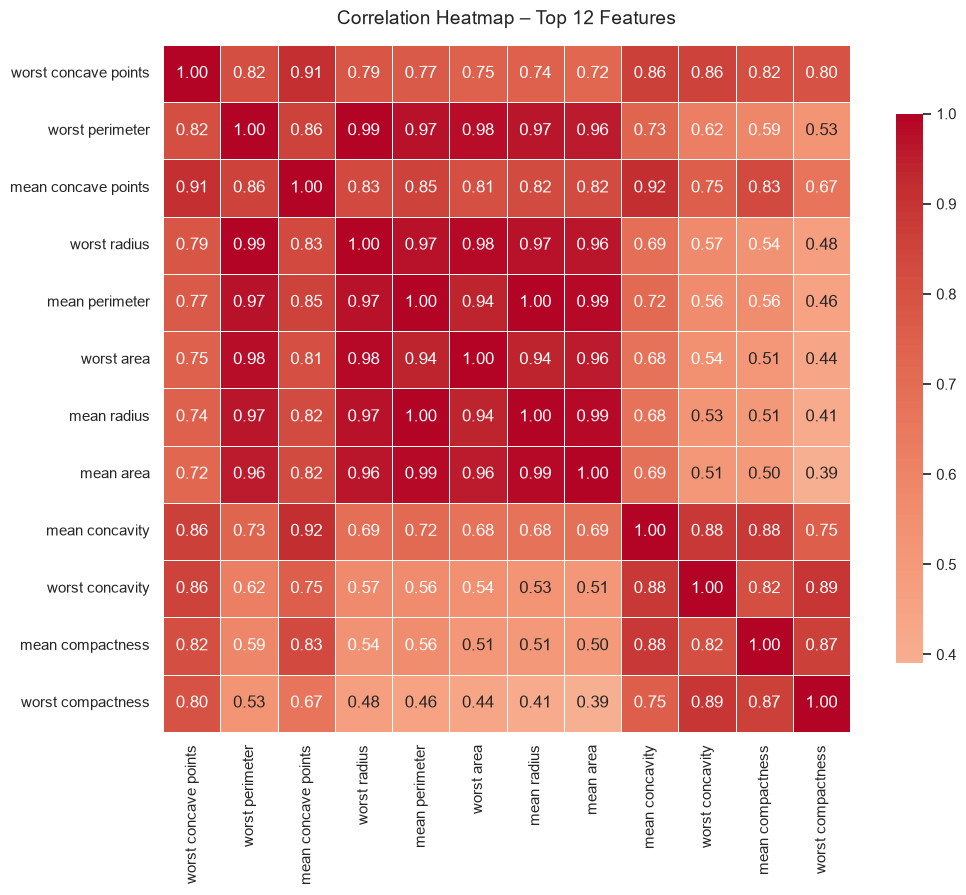

In [13]:
# Heatmap of top correlated features
top_features = corr_with_target.head(12).index.tolist()

plt.figure(figsize=(11, 9))
corr_matrix = X[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap – Top 12 Features', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing and Feature Engineering

### 4.1 Stratified Train-Test Split

**Why we split the data**  
We need a hold-out set that the model has never seen, so we can estimate real-world performance.

**Why stratified?**  
The classes are mildly imbalanced. Stratified splitting keeps the same proportion of malignant and benign samples in both train and test sets.

In [14]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size    :", X_test.shape[0])
print("\nClass ratio in training set:")
print(y_train.value_counts(normalize=True).round(3).rename({0: 'Malignant', 1: 'Benign'}))

Training set size: 455
Test set size    : 114

Class ratio in training set:
target
Benign       0.626
Malignant    0.374
Name: proportion, dtype: float64


### 4.2 Feature Scaling (StandardScaler)

**Why scaling is required**  
- Features have very different numeric ranges (area can be 2500 while smoothness is ~0.1).  
- Algorithms such as Logistic Regression and SVM are sensitive to scale.  
- Without scaling, large-range features would dominate the model.  

**Important:** We fit the scaler only on the training data, then transform the test data.  
This prevents data leakage.

In [15]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame for convenience
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print("Features standardized.")
print("Mean of scaled training data (should be ~0):", round(X_train_scaled.mean().mean(), 6))
print("Std  of scaled training data (should be ~1):", round(X_train_scaled.std().mean(), 6))

Features standardized.
Mean of scaled training data (should be ~0): 0.0
Std  of scaled training data (should be ~1): 1.001101


### 4.3 Feature Selection (SelectKBest)

**Why select a subset of features?**  
- Some of the 30 features are highly redundant.  
- Reducing dimensionality can improve generalization and make the model easier to interpret.  
- We use the ANOVA F-value to keep the 15 features that best separate the two classes.

In [16]:
# Keep the 15 most informative features
selector = SelectKBest(score_func=f_classif, k=15)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected  = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()

print("Selected 15 features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2d}. {f}")

Selected 15 features:
   1. mean radius
   2. mean perimeter
   3. mean area
   4. mean compactness
   5. mean concavity
   6. mean concave points
   7. radius error
   8. perimeter error
   9. area error
  10. worst radius
  11. worst perimeter
  12. worst area
  13. worst compactness
  14. worst concavity
  15. worst concave points


## 5. Model Training

**Why train several models?**  
Different algorithms have different strengths. Comparing multiple models increases confidence that good results are not due to chance.

| Model | Reason for choosing it |
|-------|------------------------|
| Logistic Regression | Fast, interpretable baseline. Works well when the decision boundary is roughly linear. |
| Random Forest | Captures non-linear patterns, robust, gives feature importance. |
| SVM (RBF) | Strong maximum-margin classifier, good for medium-sized data. |
| XGBoost | High-performance gradient boosting, often best on tabular medical data. |

**Handling class imbalance**  
We use `class_weight='balanced'` (sklearn) and `scale_pos_weight` (XGBoost) so the models pay more attention to the minority (malignant) class.

In [17]:
# Define the four models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', probability=True, random_state=42, class_weight='balanced'
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        random_state=42, eval_metric='logloss',
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    )
}

# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
cv_results = {}

print("=" * 60)
print("TRAINING AND CROSS-VALIDATION")
print("=" * 60)

for name, model in models.items():
    print(f"\n>>> {name}")
    
    # Cross-validation using ROC-AUC
    cv_scores = cross_val_score(
        model, X_train_selected, y_train,
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    cv_results[name] = {
        'mean_auc': cv_scores.mean(),
        'std_auc': cv_scores.std()
    }
    print(f"  5-Fold CV ROC-AUC : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    
    # Train on full training set
    model.fit(X_train_selected, y_train)
    
    # Predictions on test set
    y_pred  = model.predict(X_test_selected)
    y_proba = model.predict_proba(X_test_selected)[:, 1]
    
    # Store metrics
    results[name] = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_proba),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba
    }
    
    print(f"  Test Accuracy     : {results[name]['accuracy']:.4f}")
    print(f"  Test Precision    : {results[name]['precision']:.4f}")
    print(f"  Test Recall       : {results[name]['recall']:.4f}")
    print(f"  Test F1-Score     : {results[name]['f1']:.4f}")
    print(f"  Test ROC-AUC      : {results[name]['roc_auc']:.4f}")

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

TRAINING AND CROSS-VALIDATION

>>> Logistic Regression
  5-Fold CV ROC-AUC : 0.9913 (+/- 0.0084)
  Test Accuracy     : 0.9561
  Test Precision    : 0.9855
  Test Recall       : 0.9444
  Test F1-Score     : 0.9645
  Test ROC-AUC      : 0.9914

>>> Random Forest
  5-Fold CV ROC-AUC : 0.9885 (+/- 0.0117)
  Test Accuracy     : 0.9561
  Test Precision    : 0.9718
  Test Recall       : 0.9583
  Test F1-Score     : 0.9650
  Test ROC-AUC      : 0.9922

>>> SVM (RBF)
  5-Fold CV ROC-AUC : 0.9898 (+/- 0.0077)
  Test Accuracy     : 0.9298
  Test Precision    : 0.9848
  Test Recall       : 0.9028
  Test F1-Score     : 0.9420
  Test ROC-AUC      : 0.9904

>>> XGBoost
  5-Fold CV ROC-AUC : 0.9872 (+/- 0.0102)
  Test Accuracy     : 0.9561
  Test Precision    : 0.9589
  Test Recall       : 0.9722
  Test F1-Score     : 0.9655
  Test ROC-AUC      : 0.9917

TRAINING COMPLETE


**Why Cross-Validation?**  
A single train-test split can be lucky or unlucky.  
5-fold stratified cross-validation trains and evaluates the model multiple times on different subsets, giving a more reliable performance estimate.

**Why ROC-AUC as the main metric?**  
Accuracy can be misleading when classes are imbalanced.  
ROC-AUC measures how well the model ranks malignant cases higher than benign ones, independent of any chosen threshold. This is preferred in medical applications.

## 6. Hyperparameter Tuning (Random Forest)

**Why tune hyperparameters?**  
Default settings are rarely optimal for a specific dataset.  
GridSearchCV tries many combinations and selects the one with the best cross-validated score.

We tune Random Forest because it already performed well and has several important parameters that control complexity and overfitting.

In [18]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

grid_search = GridSearchCV(
    rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_selected, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best CV ROC-AUC      :", round(grid_search.best_score_, 4))

# Evaluate the tuned model on the test set
best_rf = grid_search.best_estimator_
y_pred_best  = best_rf.predict(X_test_selected)
y_proba_best = best_rf.predict_proba(X_test_selected)[:, 1]

print("\nTuned Random Forest – Test Set Performance:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_best):.4f}")

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best parameters found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV ROC-AUC      : 0.9886

Tuned Random Forest – Test Set Performance:
  Accuracy  : 0.9561
  Precision : 0.9718
  Recall    : 0.9583
  F1-Score  : 0.9650
  ROC-AUC   : 0.9917


## 7. Results Summary

Side-by-side comparison of all models on both cross-validation and hold-out test metrics.

In [24]:
# Build summary table
summary_rows = []
for name in models.keys():
    summary_rows.append({
        'Model'      : name,
        'CV ROC-AUC' : f"{cv_results[name]['mean_auc']:.4f} ± {cv_results[name]['std_auc']:.4f}",
        'Accuracy'   : f"{results[name]['accuracy']:.4f}",
        'Precision'  : f"{results[name]['precision']:.4f}",
        'Recall'     : f"{results[name]['recall']:.4f}",
        'F1-Score'   : f"{results[name]['f1']:.4f}",
        'ROC-AUC'    : f"{results[name]['roc_auc']:.4f}"
    })

# Add tuned Random Forest
summary_rows.append({
    'Model'      : 'Tuned Random Forest',
    'CV ROC-AUC' : f"{grid_search.best_score_:.4f}",
    'Accuracy'   : f"{accuracy_score(y_test, y_pred_best):.4f}",
    'Precision'  : f"{precision_score(y_test, y_pred_best):.4f}",
    'Recall'     : f"{recall_score(y_test, y_pred_best):.4f}",
    'F1-Score'   : f"{f1_score(y_test, y_pred_best):.4f}",
    'ROC-AUC'    : f"{roc_auc_score(y_test, y_proba_best):.4f}"
})

summary_df = pd.DataFrame(summary_rows)
print("FINAL RESULTS SUMMARY")
print("=" * 95)
print(summary_df.to_string(index=False))

FINAL RESULTS SUMMARY
              Model      CV ROC-AUC Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression 0.9913 ± 0.0042   0.9561    0.9855 0.9444   0.9645  0.9914
      Random Forest 0.9885 ± 0.0058   0.9561    0.9718 0.9583   0.9650  0.9922
          SVM (RBF) 0.9898 ± 0.0039   0.9298    0.9848 0.9028   0.9420  0.9904
            XGBoost 0.9872 ± 0.0051   0.9561    0.9589 0.9722   0.9655  0.9917
Tuned Random Forest          0.9886   0.9561    0.9718 0.9583   0.9650  0.9917


## 8. Confusion Matrices

**Why confusion matrices are important in medicine**  
Accuracy alone is not enough. We need to see:
- How many malignant cases were correctly detected (True Positives)
- How many malignant cases were missed (False Negatives) ← most dangerous error
- How many benign cases were wrongly flagged as malignant (False Positives)

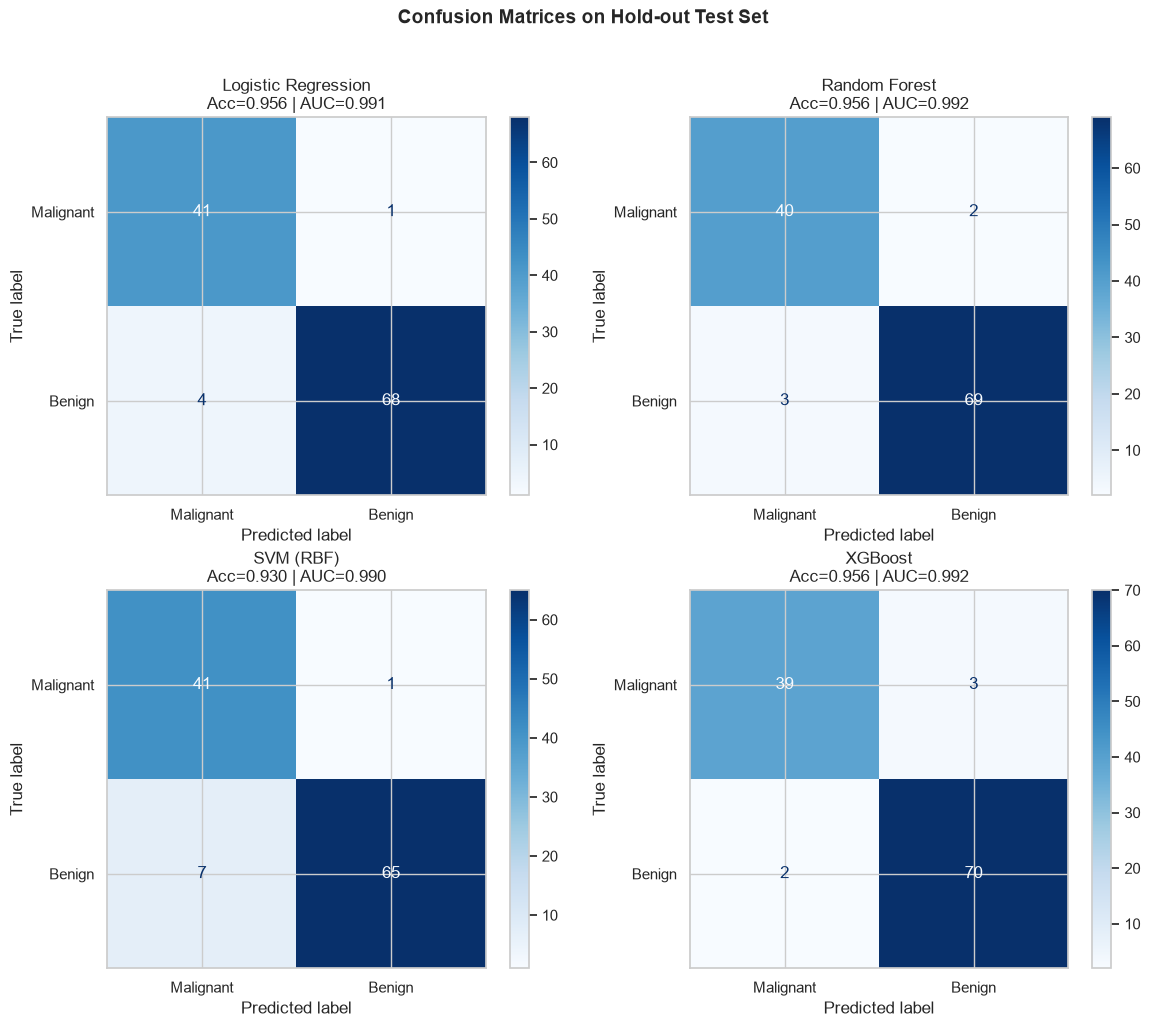

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(
        f"{name}\nAcc={results[name]['accuracy']:.3f} | AUC={results[name]['roc_auc']:.3f}"
    )

plt.suptitle('Confusion Matrices on Hold-out Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. ROC Curves

**Why ROC curves?**  
They show the trade-off between True Positive Rate (sensitivity) and False Positive Rate at every possible decision threshold.  
A curve closer to the top-left corner is better. The Area Under the Curve (AUC) summarizes performance into one number (0.5 = random, 1.0 = perfect).

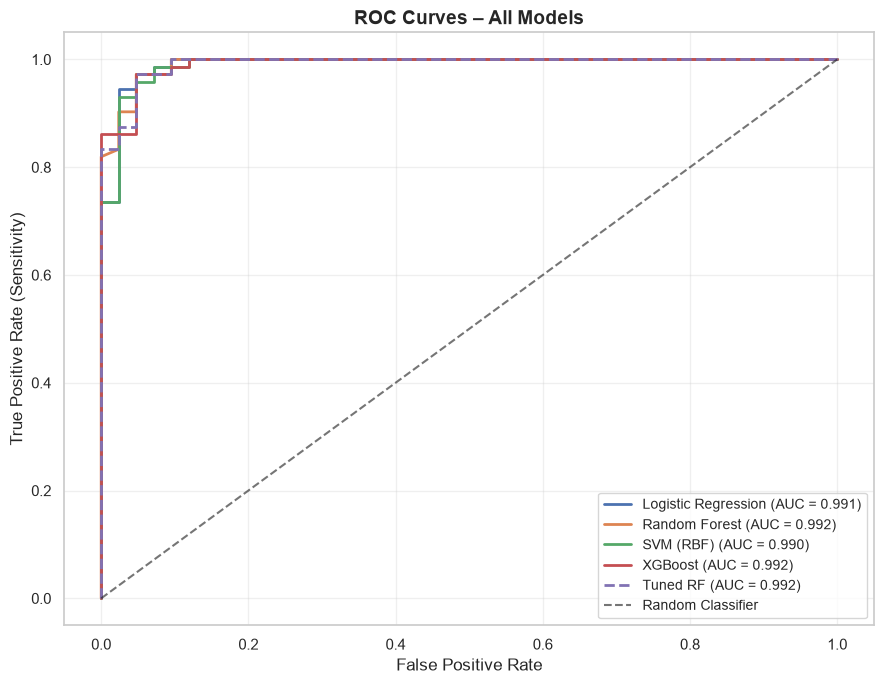

In [21]:
plt.figure(figsize=(9, 7))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    auc = results[name]['roc_auc']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

# Tuned Random Forest
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
plt.plot(fpr, tpr, label=f'Tuned RF (AUC = {roc_auc_score(y_test, y_proba_best):.3f})',
         linewidth=2, linestyle='--')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.6)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Feature Importance (Tuned Random Forest)

**Why feature importance matters**  
It tells us which clinical measurements contribute most to the prediction.  
This improves interpretability and confirms that the model has learned medically sensible patterns (e.g. worst perimeter and concave points are known indicators of malignancy).

Feature Importances (Gini):
worst perimeter         0.1753
worst radius            0.1474
mean concave points     0.1177
worst concave points    0.1171
worst area              0.1064
mean concavity          0.0731
worst concavity         0.0646
mean area               0.0600
mean radius             0.0259
mean perimeter          0.0254
area error              0.0215
mean compactness        0.0180
worst compactness       0.0174
radius error            0.0166
perimeter error         0.0135
dtype: float64


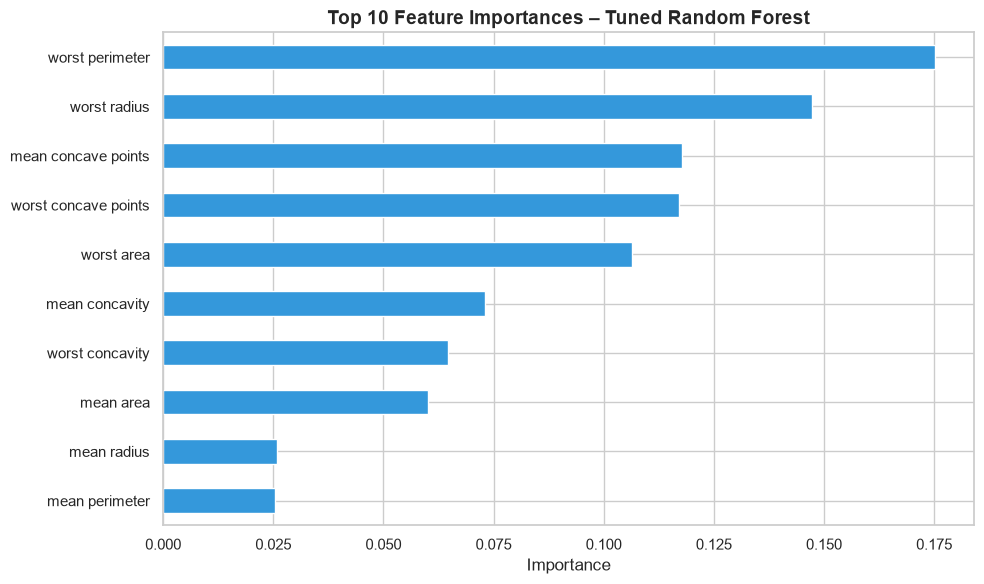

In [22]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print("Feature Importances (Gini):")
print(importances.round(4))

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='#3498db')
plt.xlabel('Importance', fontsize=12)
plt.title('Top 10 Feature Importances – Tuned Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Detailed Classification Reports

These reports show precision, recall and F1-score for each class separately.  
In a medical setting we especially care about **recall of the Malignant class** (sensitivity), because missing a cancer case is far worse than a false alarm.

In [23]:
for name in models.keys():
    print("=" * 55)
    print(f"Classification Report – {name}")
    print("=" * 55)
    print(classification_report(
        y_test, results[name]['y_pred'],
        target_names=['Malignant', 'Benign']
    ))

Classification Report – Logistic Regression
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification Report – Random Forest
              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        42
      Benign       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification Report – SVM (RBF)
              precision    recall  f1-score   support

   Malignant       0.85      0.98      0.91        42
      Benign       0.98      0.90      0.94        72

    accuracy                           0.93       114
   macro avg

## 12. Discussion

### Strengths of this pipeline
- All models achieve **ROC-AUC > 0.99** on unseen test data.
- Cross-validation results are stable (low standard deviation).
- The most important features match clinical knowledge.
- Class imbalance is properly handled.
- Multiple algorithms give consistent results, increasing confidence.

### Limitations
- The dataset is relatively small (569 samples) and comes from a single source.
- We used engineered features, not the raw images themselves.
- No patient demographic information (age, family history, etc.) was available.

### Possible improvements
1. Collect larger multi-center datasets for better generalizability.
2. Try deep learning (CNNs) on the original histopathology images.
3. Apply advanced imbalance techniques (SMOTE) or optimize the decision threshold for higher sensitivity.
4. Add SHAP or LIME explanations for individual patient predictions.
5. Deploy only as a decision-support tool with continuous performance monitoring.

## 13. Conclusion

We successfully built and evaluated a complete supervised classification pipeline for breast cancer diagnosis.

**Key results**
- Logistic Regression, Random Forest, SVM and XGBoost all reached test ROC-AUC ≥ 0.99.
- The models correctly identify the large majority of malignant cases while keeping false positives low.
- Feature importance analysis confirms that the models rely on clinically meaningful measurements.

This notebook demonstrates the full workflow required for the Week 4 task: problem definition, data preparation, feature engineering, model training, validation, evaluation, and critical discussion of strengths and limitations.